# Short-form inference experiments - Analysis

In [ ]:
# stdlib
import itertools
from typing import Tuple

# third-party
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

# first-party
from alt import util
from alt.render import HtmlSummary

# Read results
results : dict[Tuple[str, str, str], HtmlSummary]= dict()
models = ["whisper"]  # override
levels = ["song", "line", "verse"]
audios = ["original", "mdx", "mdx_extra", "htdemucs_ft", "stem"]
for model, audio, level in itertools.product(models, audios, levels): 
    if level != "song":
        if audio in ["original", "stem"]:
            name = f"02-short-{model}-{audio}-{level}"
        else:
            name = f"02-short-{audio}-{model}-separated-{level}"
    else:
        if audio in ["original", "stem"]:
            name = f"04-long-{model}-{audio}-base"
        else:
            name = f"04-long-{audio}-{model}-separated-base"
    results[(model, audio, level)] = util.read_pz(f"../../build/{name}/eval/summary_eval.pz")


In [11]:
# Load per-dataset error rates into a pandas DataFrame
data = []
for (model, audio, level), summary in results.items():
    for ds, rates in summary.ds_error_rates.items():
        data.append({
            'model': model,
            'audio': audio,
            'level': level,
            'dataset': ds,
            'wer': rates.wer,
        })
df = pd.DataFrame(data)
df.head()


,model,audio,level,dataset,wer
0,whisper,original,song,dali_gt,0.212445
1,whisper,original,song,jamendolyrics,0.246220
2,whisper,original,song,jam-alt,0.235637
3,whisper,original,song,musdb,0.293570
4,whisper,original,line,dali_gt,0.357181


In [12]:
# Create a table of WER with datasets on the rows and levels on the columns
tables = {}
datasets = pd.unique(df['dataset'])
for level in ["verse", "line"]:
    for dataset in datasets:
        df_filtered = df[(df['dataset'] == dataset) & (df['level'] == level)]
        pivot_table = df_filtered.pivot(index='model', columns='audio', values='wer')
        tables[(level, dataset)] = pivot_table
        display(Markdown(f"**{dataset}-{level}**"))
        print(pivot_table)


**dali_gt-verse**

audio    htdemucs_ft       mdx  mdx_extra  original
model                                              
whisper     0.220911  0.225547   0.234991  0.217096


**jamendolyrics-verse**

audio    htdemucs_ft       mdx  mdx_extra  original
model                                              
whisper     0.207044  0.222997   0.204894  0.225025


**jam-alt-verse**

...

audio    htdemucs_ft       mdx  mdx_extra  original
model                                              
whisper      0.29667  0.315666   0.296525  0.340756


**jam-alt-line**

audio    htdemucs_ft       mdx  mdx_extra  original
model                                              
whisper     0.296136  0.330496   0.303723  0.345021


**musdb-line**

audio    htdemucs_ft       mdx  mdx_extra  original      stem
model                                                        
whisper     0.288106  0.288525   0.270891  0.336707  0.199374


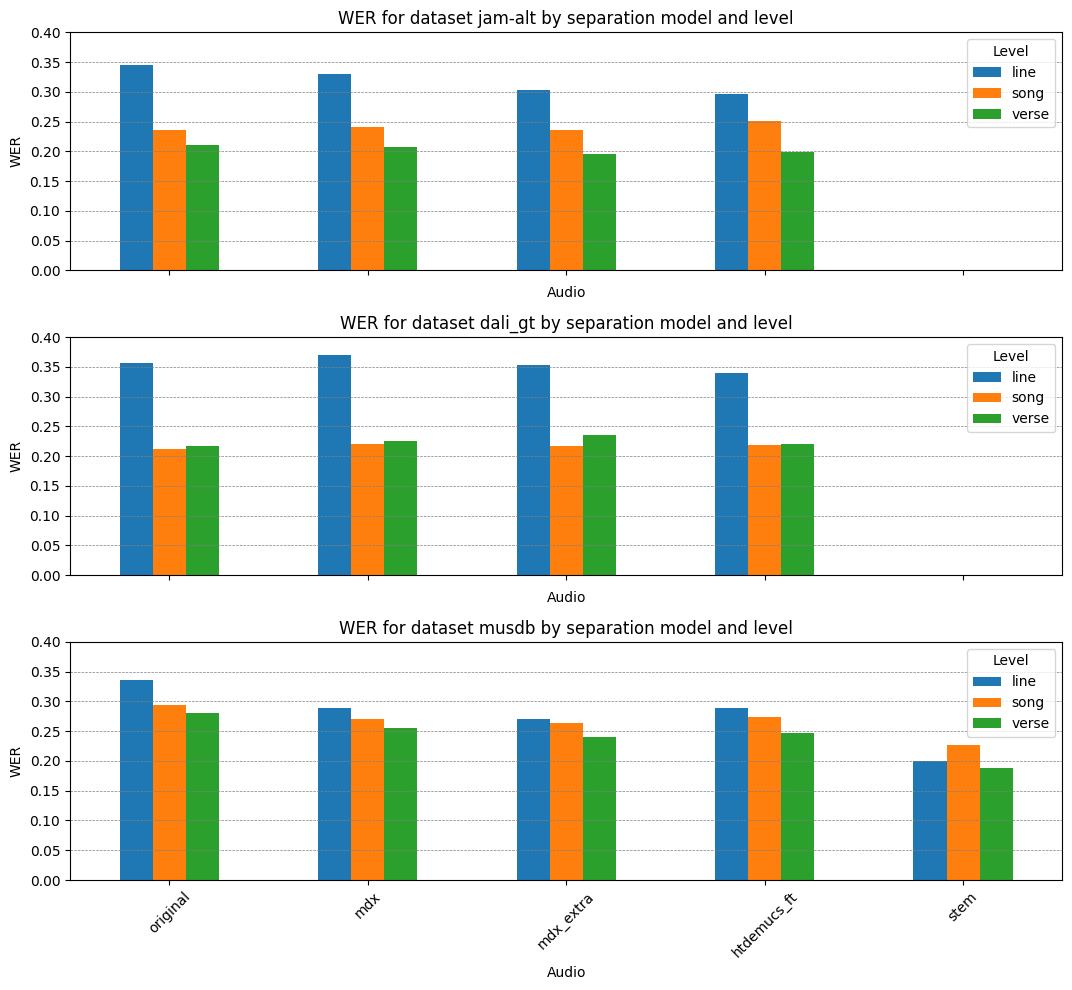

In [29]:
datasets = ["jam-alt", "dali_gt", "musdb"]
for model in ["whisper"]:
    fig, axes = plt.subplots(3, 1, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, dataset in enumerate(datasets):
        ax = axes[i]
        df_filtered = df[(df['dataset'] == dataset) & (df['model'] == model)]
        pivot_table = df_filtered.pivot(index=['audio'], columns='level', values='wer')
        pivot_table = pivot_table.reindex(["original", "mdx", "mdx_extra", "htdemucs_ft", "stem"])
        pivot_table.plot(kind='bar', ax=ax)
        if i < len(axes) - 1:
            ax.set_xticklabels([])
        ax.set_aspect(3)
        
        for ytick in ax.get_yticks():
            ax.axhline(y=ytick, color='gray', linestyle='--', linewidth=0.5)
        
        ax.set_title(f"WER for dataset {dataset} by separation model and level")
        ax.set_ylabel("WER")
        ax.set_xlabel("Audio")
        ax.set_ylim(0.0, 0.4)
        ax.legend(title='Level')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()